importing packages and libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics.pairwise import cosine_similarity,cosine_distances,euclidean_distances

DATA PREPROCESSING

Loading the dataset

In [ ]:
df=pd.read_csv('/content/anime.csv')

In [ ]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


feature data types and structural information about the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


checking missing values

In [ ]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


filling missing value with respective elements

In [ ]:
df.fillna({'genre':df.genre.mode()[0],'type':df.type.mode()[0],'rating':df.rating.median()},inplace=True)

FEATURE EXTRACTION

feature selecting for calculating similarity score

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#### vectorization
tfidf=TfidfVectorizer(stop_words='english')

In [ ]:
#### vectorization on genre feature
tfidf1=tfidf.fit_transform(df['genre'])

In [ ]:
tfidf1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40480 stored elements and shape (12294, 46)>

claculating similarites

In [ ]:
from sklearn.metrics.pairwise import sigmoid_kernel,linear_kernel,polynomial_kernel,rbf_kernel

In [ ]:
similiraties=sigmoid_kernel(tfidf1,tfidf1)
similiraties.shape

(12294, 12294)

In [ ]:
indices=pd.Series(index=df.name,data=df.index)
indices
similiraties[1]

array([0.76294071, 0.77057395, 0.76322027, ..., 0.76159416, 0.76159416,
       0.76159416])

recomandation functio for anime beased on similiarites

In [ ]:
def recommend_anime(anime_name):
    if anime_name in indices.index:
        index=np.where(anime_name==indices.index)[0][0]
        similar= sorted(list(enumerate(similiraties[index])),reverse=True,key=lambda x:x[1])[1:6]
        print(f'Recommended anime of {anime_name}')
        print('*'*30)
        for index1 in similar:
            print(indices.index[index1[0]])
    else:
        print('anime is not in the list')

In [ ]:
recommend_anime('Kimi no Na wa.')

Recommended anime of Kimi no Na wa.
******************************
Wind: A Breath of Heart OVA
Wind: A Breath of Heart (TV)
Aura: Maryuuin Kouga Saigo no Tatakai
Angel Beats!: Another Epilogue
Harmonie


Data visualization on various features though bar plot

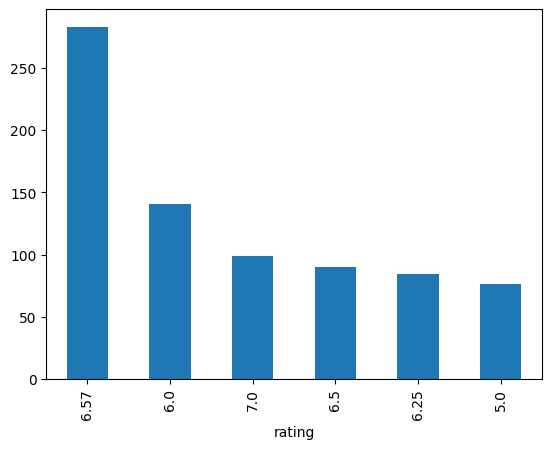

In [ ]:
df.rating.value_counts().head(6).plot(kind='bar')
plt.show()

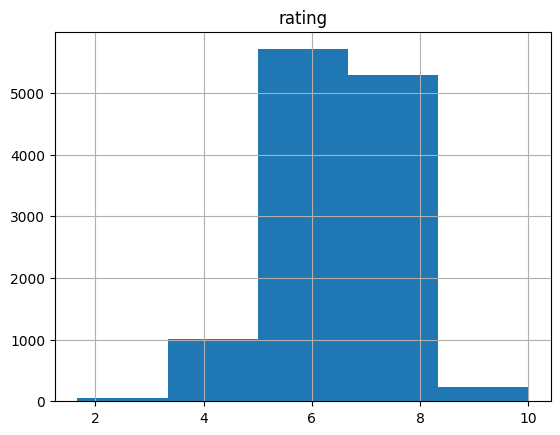

In [ ]:
df.hist('rating',bins=5)
plt.show()

ploting the barplot of top 6 genre based on ratings

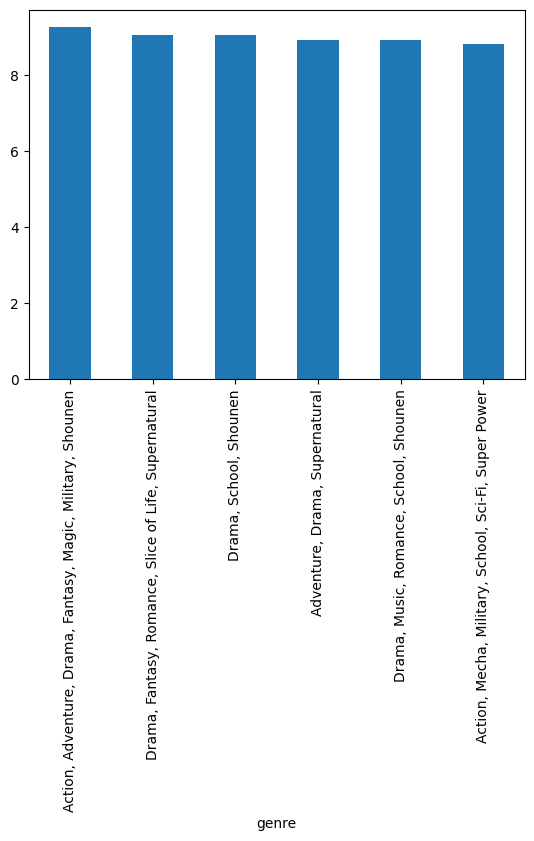

In [ ]:
df.groupby('genre')['rating'].mean().sort_values(ascending=False)[:6].plot(kind='bar')
plt.show()

ploting of top 6 anime name by ratings

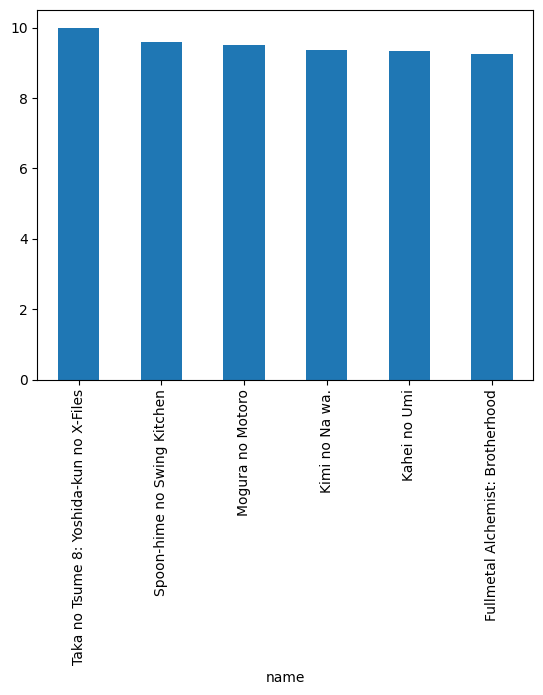

In [ ]:
df.groupby('name')['rating'].mean().sort_values(ascending=False)[:6].plot(kind='bar')
plt.show()

type vs rating

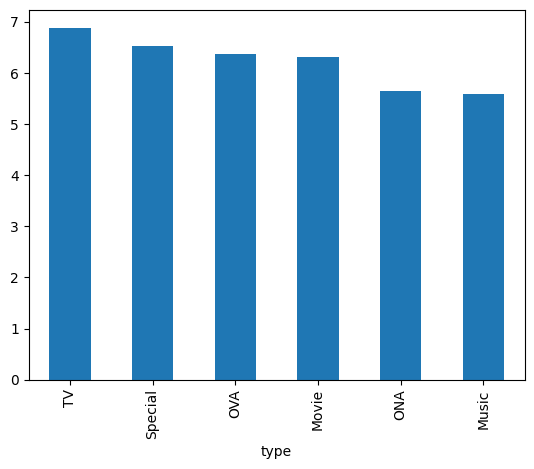

In [ ]:
df.groupby('type')['rating'].mean().sort_values(ascending=False)[:6].plot(kind='bar')
plt.show()

genre vs members

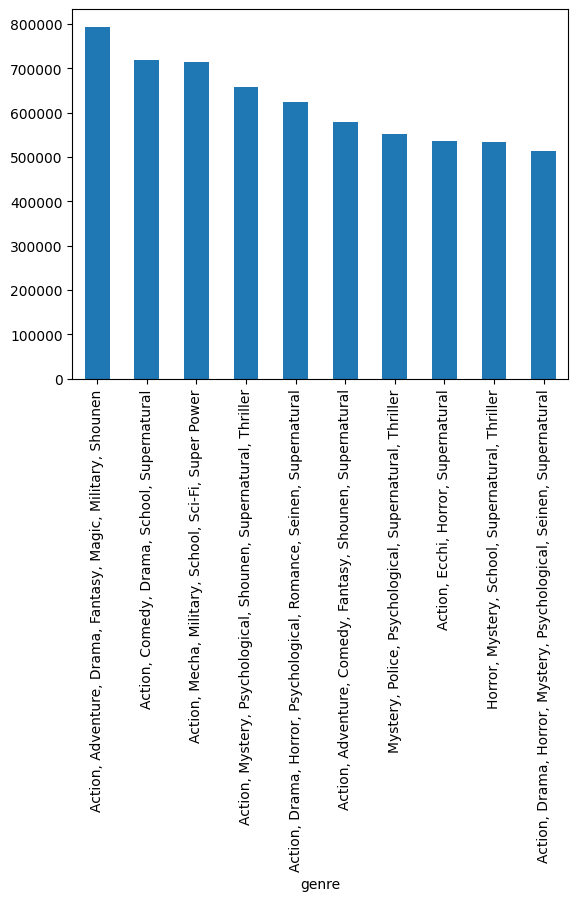

In [ ]:
df.groupby('genre')['members'].mean().sort_values(ascending=False)[:10].plot(kind='bar')
plt.show()

type vs members

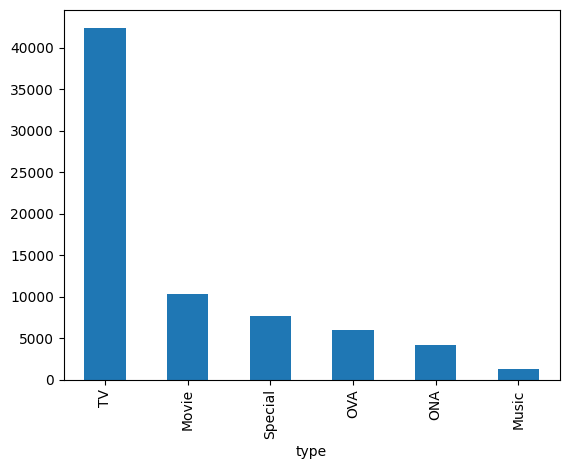

In [ ]:
df.groupby('type')['members'].mean().sort_values(ascending=False)[:6].plot(kind='bar')
plt.show()

recomandation enginee through item based

In [ ]:
##### cosine similarity
### item based

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
df["genre_list"] = df["genre"].apply(lambda x: x.split(", "))
# Multi-hot encode genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df["genre_list"])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df["name"])
# Now df1 is anime vs genre matrix
df1 = genre_df

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
cos_sim = cosine_similarity(df1.values)


In [ ]:
def recommend_anime(anime_name, top_n=20, threshold=0.4):
    if anime_name in df1.index:
        index = np.where(df1.index == anime_name)[0][0]
        scores = list(enumerate(cos_sim[index]))
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        recommendations = []
        for i, score in scores[1:]:
            if threshold is None or score >= threshold:
                recommendations.append((df1.index[i], score))
            if top_n is not None and len(recommendations) >= top_n:
                break
        return recommendations
        for rec, score in recommendations:
            print(f"{rec} (similarity: {score:.2f})")
    else:
        print(f"{anime_name} not found in dataset")
        return []

In [ ]:
recommand_anime('Gintama&#039;')

Recommended anime for Gintama&#039;:
Gintama&#039;
Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare
Gintama&#039;: Enchousen
Gintama
Gintama: Yorinuki Gintama-san on Theater 2D


In [ ]:
thresholds = [0.2, 0.4, 0.6, 0.8]
results = {}

for t in thresholds:
    recs = recommend_anime("Naruto", top_n=None, threshold=t)
    list_size = len(recs)
    avg_score = np.mean([score for _, score in recs]) if recs else 0
    results[t] = {"size": list_size, "avg_score": avg_score}

# Display results
for t, metrics in results.items():
    print(f"Threshold {t}: List size={metrics['size']}, Avg similarity={metrics['avg_score']:.2f}")

Threshold 0.2: List size=6168, Avg similarity=0.36
Threshold 0.4: List size=2048, Avg similarity=0.52
Threshold 0.6: List size=455, Avg similarity=0.68
Threshold 0.8: List size=23, Avg similarity=0.91


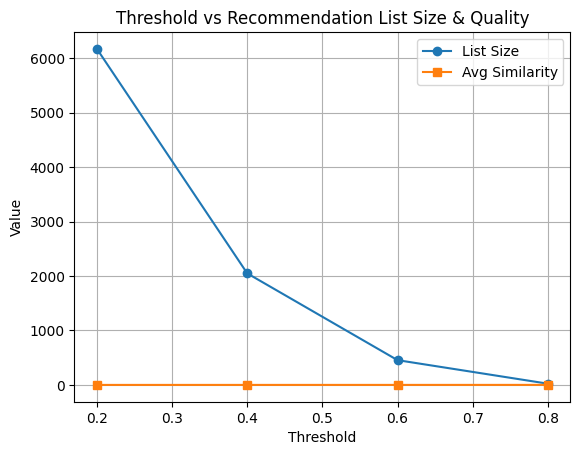

In [ ]:
import matplotlib.pyplot as plt

plt.plot(results.keys(), [m["size"] for m in results.values()], label="List Size", marker='o')
plt.plot(results.keys(), [m["avg_score"] for m in results.values()], label="Avg Similarity", marker='s')
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.title("Threshold vs Recommendation List Size & Quality")
plt.legend()
plt.grid(True)
plt.show()

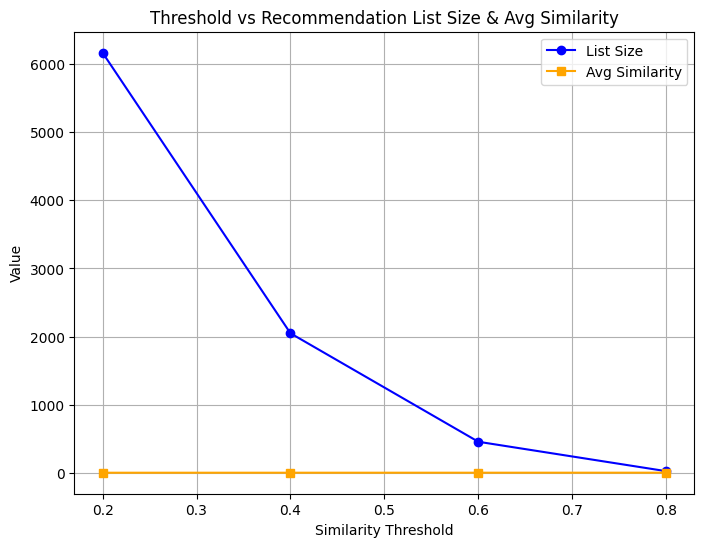

In [ ]:
import matplotlib.pyplot as plt

# Your results from the sweep
thresholds = [0.2, 0.4, 0.6, 0.8]
list_sizes = [6168, 2048, 455, 23]
avg_similarities = [0.36, 0.52, 0.68, 0.91]

plt.figure(figsize=(8,6))

# Plot list size
plt.plot(thresholds, list_sizes, label="List Size", marker='o', color='blue')
# Plot average similarity
plt.plot(thresholds, avg_similarities, label="Avg Similarity", marker='s', color='orange')

plt.xlabel("Similarity Threshold")
plt.ylabel("Value")
plt.title("Threshold vs Recommendation List Size & Avg Similarity")
plt.legend()
plt.grid(True)
plt.show()

Performance insights
    Optimal zone is 0.5 - 0.6
         list is manageable and similarity score are strong

improvent areas

*   Hybrid strategy
*   Feature engineering
*   Diversity Boosting
*   Visualization






Interview questions and answers

1. Can you explain the difference between user-based and item-based collaborative filtering?

User-based collaborative Filtering:
  --- find users who are similar to the target user and recommend items they liked.
  --- compute similarity between users using cosine similarity or pearson correlation.
  
Item-based collaborative Filtering:
  --- fnd items similar to the ones the user has already liked and recommend those.
  --- for each item the user likes,find other items that sre similiar

2. What is collaborative filtering, and how does it work?

--- Collaborative filtering uses user-item interaction patterns to make recommendations.

--- build a user-item interaction matrix

--- measures similarity either between users or items

--- predict missing ratings or recommend items based on similarities